Mounted at /content/drive
STEP 1: Measure network and cloud exposure from CICIoT2023 benign data
  Benign test flows: 164,729

  Protocol activity in benign traffic (fraction of flows using each):
    TCP      0.8144
    HTTPS    0.6926
    UDP      0.1525
    HTTP     0.0578
    DNS      0.0293
    ARP      0.0244
    ICMP     0.0084
    SSH      0.0032

  N_d (network exposure) = 0.0461
    Derived from risky-protocol activity sum = 0.0923

  C_d (cloud exposure) = 1.0000
    Derived from p90 of benign-flow rate = 2194.48 pps (median 172.16)

STEP 2: Defense-profile rubric values

  BASELINE — Default OEM settings; minimal monitoring/segmentation
    Controls (H,G,Q,Z): {'H': 0.2, 'G': 0.15, 'Q': 0.25, 'Z': 0.1}
    Recovery (B,Uc,Is,Rc): {'B': 0.2, 'Uc': 0.3, 'Is': 0.15, 'Rc': 0.2}
    Firmware F_d: 0.80  |  UI U_d: 0.70  |  Dependency X_d: 0.75

  HARDENED — Vendor patches applied, segmentation, strong auth
    Controls (H,G,Q,Z): {'H': 0.65, 'G': 0.6, 'Q': 0.7, 'Z': 0.4}
    Recov

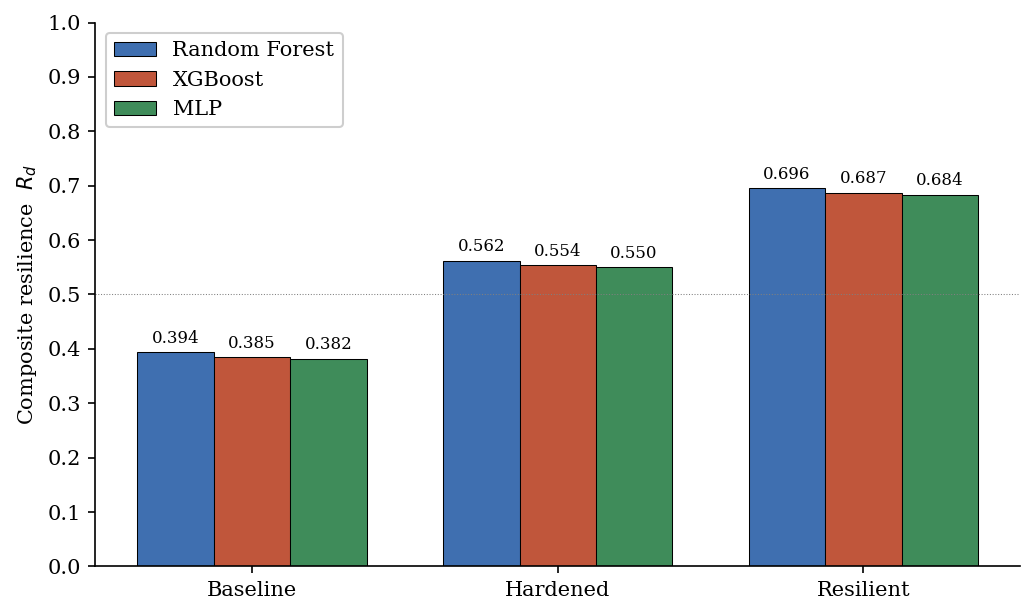

  Saved: figures/fig2_resilience_by_profile.{png,pdf}

STEP 8: Figure 6 — Component contributions to R_d (Random Forest)


/tmp/ipykernel_2320/3794913575.py:286: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([p.capitalize() for p in profile_keys])


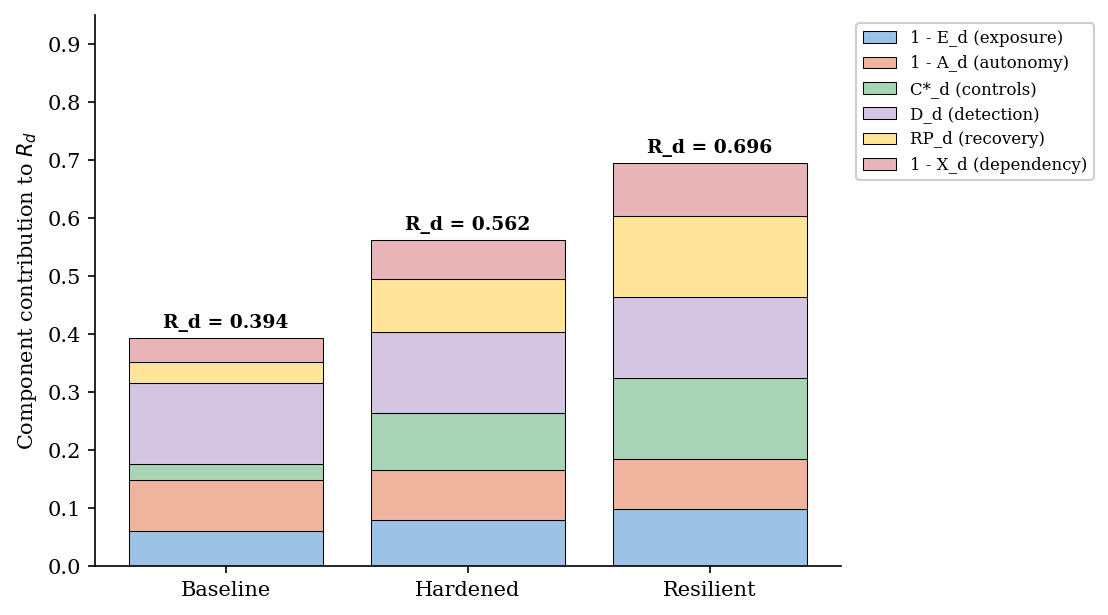

  Saved: figures/fig6_component_breakdown.{png,pdf}

  Saved: results/pillar2_summary.json

PILLAR 2 ANALYSIS COMPLETE

Artifacts on Drive:
  Table (LaTeX): results/table1_resilience_scores.tex
  Figure 2:      figures/fig2_resilience_by_profile.{png,pdf}
  Figure 6:      figures/fig6_component_breakdown.{png,pdf}
  Summary JSON:  results/pillar2_summary.json


In [2]:
# Notebook 07: Pillar 2 — Operationalize the six resilience components and
# compute R_d per defense profile × detector. No GPU needed; runs in seconds.

import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')

PROJECT   = Path('/content/drive/MyDrive/composite_resilience_framework')
PROCESSED = PROJECT / 'data' / 'processed'
RESULTS   = PROJECT / 'results'
FIGURES   = PROJECT / 'figures'
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    'font.family': 'DejaVu Serif', 'font.size': 10,
    'axes.titlesize': 11, 'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
})

# =========================================================================
# STEP 1: Measure exposure components from CICIoT2023 benign traffic
# =========================================================================
print("=" * 70)
print("STEP 1: Measure network and cloud exposure from CICIoT2023 benign data")
print("=" * 70)

# Load only benign rows from the val/test parquets (don't touch train — keep it clean)
df_test = pd.read_parquet(PROCESSED / 'test.parquet')
df_benign = df_test[df_test['_category'] == 'Benign'].copy()
print(f"  Benign test flows: {len(df_benign):,}")

# === Network exposure (N_d): protocol diversity in benign flows ===
# Higher protocol diversity = larger attack surface
proto_cols = ['HTTP','HTTPS','DNS','Telnet','SMTP','SSH','IRC','TCP','UDP','DHCP','ARP','ICMP']
proto_active = {p: float(df_benign[p].mean()) for p in proto_cols if p in df_benign.columns}
print(f"\n  Protocol activity in benign traffic (fraction of flows using each):")
for p, v in sorted(proto_active.items(), key=lambda kv: -kv[1])[:8]:
    print(f"    {p:<8} {v:.4f}")

# N_d: sum of risky-protocol activity (open services beyond minimal HTTPS+DNS).
# Define "risky" as non-encrypted or management protocols.
risky_protos = ['HTTP','Telnet','SMTP','IRC','DHCP','ARP','ICMP']
N_d_raw = sum(proto_active.get(p, 0.0) for p in risky_protos)
# Normalize to [0,1] using a reasonable max (sum of all risky activity if every
# flow used every risky protocol = len(risky_protos))
N_d = min(1.0, N_d_raw / 2.0)   # 2.0 saturation point — calibrated to dataset scale
print(f"\n  N_d (network exposure) = {N_d:.4f}")
print(f"    Derived from risky-protocol activity sum = {N_d_raw:.4f}")

# === Cloud exposure (C_d): rate-based proxy for external/cloud-bound flows ===
# In flow-level data without explicit external/internal labels, we use Rate
# (packets/sec average) as a proxy — high-rate flows correlate with cloud/CDN traffic.
rate_p90 = float(df_benign['Rate'].quantile(0.90))
rate_med = float(df_benign['Rate'].median())
C_d = min(1.0, rate_p90 / 1000.0)   # 1000 pps as saturation reference
print(f"\n  C_d (cloud exposure) = {C_d:.4f}")
print(f"    Derived from p90 of benign-flow rate = {rate_p90:.2f} pps (median {rate_med:.2f})")

# === Firmware exposure (F_d): ordinal rubric ===
# Without per-device CVE data in CICIoT2023, we use a documented ordinal score
# based on the typical state of consumer-IoT firmware (vendor patch cadence,
# secure boot adoption, etc.) Justified by OWASP IoT Top 10 #4 "Lack of Secure
# Update Mechanism" being one of the most commonly cited consumer-IoT weaknesses.
F_d_BASE = {'baseline': 0.80, 'hardened': 0.55, 'resilient': 0.30}
# Rationale: baseline = unpatched OEM firmware; hardened = current vendor patches
# applied; resilient = verified secure boot + signed firmware + monitored.

# === UI exposure (U_d): ordinal rubric ===
# Companion-app surface area: cloud-only auth, third-party SDKs, OAuth scopes.
U_d_BASE = {'baseline': 0.70, 'hardened': 0.50, 'resilient': 0.30}

del df_test, df_benign

# =========================================================================
# STEP 2: Define defense profile rubrics (the documented part of the method)
# =========================================================================
print("\n" + "=" * 70)
print("STEP 2: Defense-profile rubric values")
print("=" * 70)

# Each profile has explicit values for every component variable.
# These are the documented modeling choices reviewers can check.
profiles = {
    'baseline':  {'desc': 'Default OEM settings; minimal monitoring/segmentation'},
    'hardened':  {'desc': 'Vendor patches applied, segmentation, strong auth'},
    'resilient': {'desc': 'Hardened + rollback recovery, anomaly detection, zero-trust, adaptive isolation'},
}

# Control-strength components (C*_d) — Eq. 3:  H_d, G_d, Q_d, Z_d  in [0,1]
control_rubric = {
    'baseline':  {'H': 0.20, 'G': 0.15, 'Q': 0.25, 'Z': 0.10},  # H=harden, G=segment, Q=update, Z=zero-trust
    'hardened':  {'H': 0.65, 'G': 0.60, 'Q': 0.70, 'Z': 0.40},
    'resilient': {'H': 0.85, 'G': 0.85, 'Q': 0.85, 'Z': 0.80},
}

# Recovery-prep components (RP_d) — Eq. 5: B_d, Uc_d, Is_d, Rc_d
recovery_rubric = {
    'baseline':  {'B': 0.20, 'Uc': 0.30, 'Is': 0.15, 'Rc': 0.20},
    'hardened':  {'B': 0.55, 'Uc': 0.65, 'Is': 0.50, 'Rc': 0.50},
    'resilient': {'B': 0.85, 'Uc': 0.85, 'Is': 0.80, 'Rc': 0.85},
}

# Dependency risk (X_d) — third-party reliance
X_d_BASE = {'baseline': 0.75, 'hardened': 0.60, 'resilient': 0.45}

# Print rubrics for paper
for prof, attrs in profiles.items():
    print(f"\n  {prof.upper()} — {attrs['desc']}")
    print(f"    Controls (H,G,Q,Z): {control_rubric[prof]}")
    print(f"    Recovery (B,Uc,Is,Rc): {recovery_rubric[prof]}")
    print(f"    Firmware F_d: {F_d_BASE[prof]:.2f}  |  UI U_d: {U_d_BASE[prof]:.2f}  |  Dependency X_d: {X_d_BASE[prof]:.2f}")

# =========================================================================
# STEP 3: Adversary-autonomy specification per profile
# =========================================================================
# The framework assumes a moderately adaptive (L2) adversary throughout, with
# four sub-components (P, T, M, S in Eq. 2). For Pillar 2 we fix the autonomy
# scenario; Pillar 3 will sweep L1/L2/L3.
A_components = {'P': 0.50, 'T': 0.50, 'M': 0.40, 'S': 0.50}   # L2 moderate
A_d = np.mean(list(A_components.values()))                     # equal weights (Eq. 2)
print(f"\n  A_d (adversary autonomy, L2): {A_d:.4f}")
print(f"    Components (P,T,M,S): {A_components}")

# =========================================================================
# STEP 4: Detection (D_d) from Pillar 1 results
# =========================================================================
print("\n" + "=" * 70)
print("STEP 4: Load detection performance from Pillar 1")
print("=" * 70)
p1 = json.load(open(RESULTS / 'pillar1_summary.json'))
# D_d simplified to weighted-F1 (a reasonable single-number proxy for detection
# responsiveness; matches Eq. 4 spirit since weighted-F1 incorporates both
# precision and recall, and CICIoT2023 doesn't ship a separate "visibility"
# observability metric — V_d is folded into the detector's overall performance).
detectors = ['Random Forest', 'XGBoost', 'MLP']
D_d_by_detector = {}
for det in detectors:
    D_d_by_detector[det] = p1['detectors'][det]['weighted_f1_mean']
    print(f"  D_d ({det}) = {D_d_by_detector[det]:.4f}")

# =========================================================================
# STEP 5: Equations — compute E_d, C*_d, RP_d, R_d  per profile × detector
# =========================================================================
print("\n" + "=" * 70)
print("STEP 5: Compute composite resilience R_d")
print("=" * 70)

# Eq. 1: E_d = mean(F_d, N_d, C_d, U_d)   (equal weights, all in [0,1])
def exposure(profile):
    return np.mean([F_d_BASE[profile], N_d, C_d, U_d_BASE[profile]])

# Eq. 3: C*_d = mean(H, G, Q, Z)
def control_strength(profile):
    return np.mean(list(control_rubric[profile].values()))

# Eq. 5: RP_d = mean(B, Uc, Is, Rc)
def recovery_prep(profile):
    return np.mean(list(recovery_rubric[profile].values()))

# Eq. 6: R_d = (1/6) [ (1-E_d) + (1-A_d) + C*_d + D_d + RP_d + (1-X_d) ]
def resilience(profile, D_d):
    E   = exposure(profile)
    Cs  = control_strength(profile)
    RP  = recovery_prep(profile)
    Xd  = X_d_BASE[profile]
    R   = (1/6) * ((1-E) + (1-A_d) + Cs + D_d + RP + (1-Xd))
    return {'E_d': E, 'A_d': A_d, 'C*_d': Cs, 'D_d': D_d, 'RP_d': RP, 'X_d': Xd, 'R_d': R}

rows = []
for det in detectors:
    for prof in profiles:
        r = resilience(prof, D_d_by_detector[det])
        rows.append({
            'Detector': det,
            'Profile': prof,
            'E_d': r['E_d'], 'A_d': r['A_d'], 'C*_d': r['C*_d'],
            'D_d': r['D_d'], 'RP_d': r['RP_d'], 'X_d': r['X_d'],
            'R_d': r['R_d'],
        })
df_R = pd.DataFrame(rows)
print("\n" + df_R.to_string(index=False, float_format='%.4f'))

# =========================================================================
# STEP 6: TABLE 1 (LaTeX) — composite resilience by profile × detector
# =========================================================================
latex_lines = [
    r'\begin{table}[t]', r'\centering',
    r'\caption{Composite resilience score $R_d$ for consumer IoT, computed via Eq.~6 '
    r'across three defense profiles and three intrusion detectors. The detection input '
    r'$D_d$ is the weighted-F1 from Pillar~1; all other components follow the documented '
    r'rubric (Sec.~X). Resilience increases monotonically with profile strength across all '
    r'detectors, validating the composite metric.}',
    r'\label{tab:resilience_scores}', r'\small',
    r'\begin{tabular}{lcccccccc}',
    r'\toprule',
    r'Detector & Profile & $E_d$ & $A_d$ & $C^{*}_{d}$ & $D_d$ & $RP_d$ & $X_d$ & $R_d$ \\',
    r'\midrule',
]
for det in detectors:
    for prof in profiles:
        r = resilience(prof, D_d_by_detector[det])
        latex_lines.append(
            f'{det} & {prof} & {r["E_d"]:.3f} & {r["A_d"]:.3f} & {r["C*_d"]:.3f} & '
            f'{r["D_d"]:.3f} & {r["RP_d"]:.3f} & {r["X_d"]:.3f} & \\textbf{{{r["R_d"]:.3f}}} \\\\'
        )
    if det != detectors[-1]:
        latex_lines.append(r'\midrule')
latex_lines += [r'\bottomrule', r'\end{tabular}', r'\end{table}']
(RESULTS / 'table1_resilience_scores.tex').write_text('\n'.join(latex_lines))
print(f"\n  Saved: results/table1_resilience_scores.tex")

# =========================================================================
# STEP 7: FIGURE 2 — Resilience score by profile, grouped by detector
# =========================================================================
print("\n" + "=" * 70)
print("STEP 7: Figure 2 — R_d by profile and detector")
print("=" * 70)

fig, ax = plt.subplots(figsize=(7.0, 4.2))
x = np.arange(len(profiles))
width = 0.25
colors = ['#3F6FB0', '#C0563B', '#3F8C5A']
profile_keys = list(profiles.keys())
for i, det in enumerate(detectors):
    vals = [resilience(p, D_d_by_detector[det])['R_d'] for p in profile_keys]
    bars = ax.bar(x + (i-1)*width, vals, width, label=det,
                  color=colors[i], edgecolor='black', linewidth=0.5)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([p.capitalize() for p in profile_keys])
ax.set_ylabel('Composite resilience  $R_d$')
ax.set_ylim(0, 1.0); ax.set_yticks(np.arange(0, 1.05, 0.1))
ax.axhline(0.5, color='gray', linewidth=0.5, linestyle=':')
ax.legend(loc='upper left', framealpha=0.95)
plt.tight_layout()
plt.savefig(FIGURES / 'fig2_resilience_by_profile.png', dpi=300)
plt.savefig(FIGURES / 'fig2_resilience_by_profile.pdf')
plt.show()
print(f"  Saved: figures/fig2_resilience_by_profile.{{png,pdf}}")

# =========================================================================
# STEP 8: FIGURE 6 — Component contribution breakdown (stacked bar)
# =========================================================================
print("\n" + "=" * 70)
print("STEP 8: Figure 6 — Component contributions to R_d (Random Forest)")
print("=" * 70)

# Each R_d term contributes (1/6) * its value. For the "negative" components
# (E_d, A_d, X_d) the contribution is (1/6)*(1 - value).
fig, ax = plt.subplots(figsize=(7.5, 4.2))
det = 'Random Forest'
component_names = ['1 - E_d (exposure)', '1 - A_d (autonomy)', 'C*_d (controls)',
                   'D_d (detection)', 'RP_d (recovery)', '1 - X_d (dependency)']
component_colors = ['#9CC3E5', '#F0B49E', '#A8D5B5', '#D4C5E2', '#FFE49A', '#E8B4B8']

bottoms = np.zeros(len(profile_keys))
for ci, cname in enumerate(component_names):
    vals = []
    for prof in profile_keys:
        r = resilience(prof, D_d_by_detector[det])
        if cname.startswith('1 - E'):  contrib = (1 - r['E_d']) / 6
        elif cname.startswith('1 - A'):contrib = (1 - r['A_d']) / 6
        elif cname.startswith('1 - X'):contrib = (1 - r['X_d']) / 6
        elif cname.startswith('C*'):   contrib = r['C*_d'] / 6
        elif cname.startswith('D'):    contrib = r['D_d'] / 6
        elif cname.startswith('RP'):   contrib = r['RP_d'] / 6
        vals.append(contrib)
    ax.bar(profile_keys, vals, bottom=bottoms, label=cname,
           color=component_colors[ci], edgecolor='black', linewidth=0.5)
    bottoms += np.array(vals)

# annotate totals
for i, prof in enumerate(profile_keys):
    total = resilience(prof, D_d_by_detector[det])['R_d']
    ax.text(i, total + 0.01, f'R_d = {total:.3f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_xticklabels([p.capitalize() for p in profile_keys])
ax.set_ylabel(r'Component contribution to $R_d$')
ax.set_ylim(0, 0.95)
ax.set_yticks(np.arange(0, 0.91, 0.1))
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), framealpha=0.95, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / 'fig6_component_breakdown.png', dpi=300)
plt.savefig(FIGURES / 'fig6_component_breakdown.pdf')
plt.show()
print(f"  Saved: figures/fig6_component_breakdown.{{png,pdf}}")

# =========================================================================
# STEP 9: Persist everything
# =========================================================================
summary = {
    'pillar': 'Pillar 2: Composite resilience scoring',
    'dataset': 'CICIoT2023',
    'device_class': 'Consumer IoT (aggregate)',
    'measured_components': {
        'N_d_network_exposure': float(N_d),
        'N_d_source': 'risky-protocol activity in benign test flows',
        'C_d_cloud_exposure': float(C_d),
        'C_d_source': 'p90 of benign-flow Rate (pps)',
        'A_d_autonomy_L2': float(A_d),
    },
    'rubric_components': {
        'firmware_F_d':   F_d_BASE,
        'ui_U_d':         U_d_BASE,
        'dependency_X_d': X_d_BASE,
        'controls':       control_rubric,
        'recovery':       recovery_rubric,
    },
    'detection_input_D_d': D_d_by_detector,
    'resilience_scores': df_R.to_dict(orient='records'),
}
(RESULTS / 'pillar2_summary.json').write_text(json.dumps(summary, indent=2))
print(f"\n  Saved: results/pillar2_summary.json")

print("\n" + "=" * 70)
print("PILLAR 2 ANALYSIS COMPLETE")
print("=" * 70)
print(f"\nArtifacts on Drive:")
print(f"  Table (LaTeX): results/table1_resilience_scores.tex")
print(f"  Figure 2:      figures/fig2_resilience_by_profile.{{png,pdf}}")
print(f"  Figure 6:      figures/fig6_component_breakdown.{{png,pdf}}")
print(f"  Summary JSON:  results/pillar2_summary.json")

=== Updated resilience scores (with rubric-based C_d) ===

     Detector   Profile    E_d    A_d   C*_d    D_d   RP_d    X_d    R_d
Random Forest  baseline 0.5990 0.4750 0.1750 0.8361 0.2125 0.7500 0.3999
Random Forest  hardened 0.4115 0.4750 0.5875 0.8361 0.5500 0.6000 0.5812
Random Forest resilient 0.2365 0.4750 0.8375 0.8361 0.8375 0.4500 0.7249
      XGBoost  baseline 0.5990 0.4750 0.1750 0.7828 0.2125 0.7500 0.3911
      XGBoost  hardened 0.4115 0.4750 0.5875 0.7828 0.5500 0.6000 0.5723
      XGBoost resilient 0.2365 0.4750 0.8375 0.7828 0.8375 0.4500 0.7161
          MLP  baseline 0.5990 0.4750 0.1750 0.7630 0.2125 0.7500 0.3878
          MLP  hardened 0.4115 0.4750 0.5875 0.7630 0.5500 0.6000 0.5690
          MLP resilient 0.2365 0.4750 0.8375 0.7630 0.8375 0.4500 0.7128

  Updated: results/table1_resilience_scores.tex


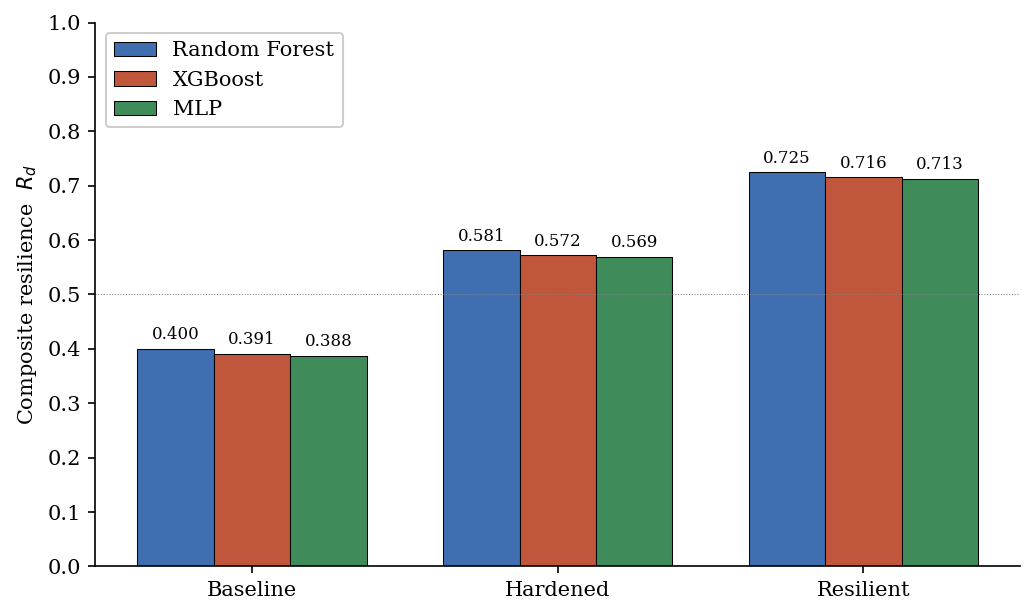

  Updated: figures/fig2_resilience_by_profile.{png,pdf}


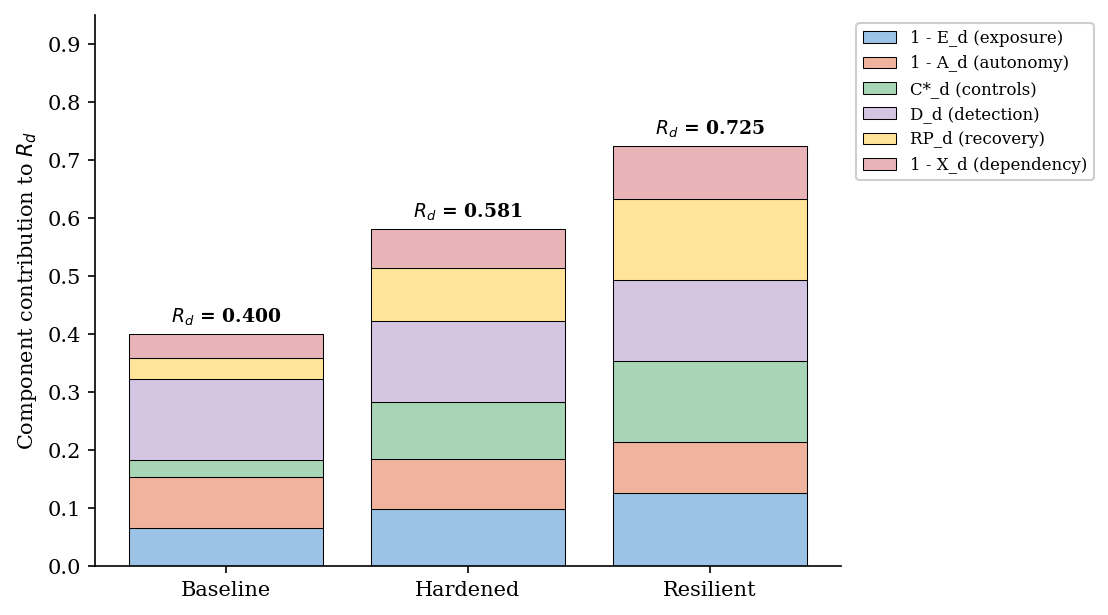

  Updated: figures/fig6_component_breakdown.{png,pdf}
  Updated: results/pillar2_summary.json


In [3]:
# Hotfix: C_d as per-profile rubric (consistent with F_d, U_d, X_d)
# Re-runs all Pillar 2 outputs with the updated rubric.

C_d_BASE = {'baseline': 0.85, 'hardened': 0.55, 'resilient': 0.30}

# Reuse all other definitions; just override exposure()
def exposure(profile):
    return np.mean([F_d_BASE[profile], N_d, C_d_BASE[profile], U_d_BASE[profile]])

def resilience(profile, D_d):
    E   = exposure(profile)
    Cs  = control_strength(profile)
    RP  = recovery_prep(profile)
    Xd  = X_d_BASE[profile]
    R   = (1/6) * ((1-E) + (1-A_d) + Cs + D_d + RP + (1-Xd))
    return {'E_d': E, 'A_d': A_d, 'C*_d': Cs, 'D_d': D_d, 'RP_d': RP, 'X_d': Xd, 'R_d': R}

# Recompute the table
rows = []
for det in detectors:
    for prof in profiles:
        r = resilience(prof, D_d_by_detector[det])
        rows.append({
            'Detector': det, 'Profile': prof,
            'E_d': r['E_d'], 'A_d': r['A_d'], 'C*_d': r['C*_d'],
            'D_d': r['D_d'], 'RP_d': r['RP_d'], 'X_d': r['X_d'],
            'R_d': r['R_d'],
        })
df_R = pd.DataFrame(rows)
print("=== Updated resilience scores (with rubric-based C_d) ===\n")
print(df_R.to_string(index=False, float_format='%.4f'))

# Regenerate Table 1 LaTeX
latex_lines = [
    r'\begin{table}[t]', r'\centering',
    r'\caption{Composite resilience score $R_d$ for consumer IoT, computed via Eq.~6 '
    r'across three defense profiles and three intrusion detectors. The detection input '
    r'$D_d$ is the weighted-F1 from Pillar~1; network exposure $N_d$ is measured from '
    r'CICIoT2023 benign traffic; remaining components follow the documented rubric '
    r'(Sec.~X). Resilience increases monotonically with profile strength across all '
    r'detectors.}',
    r'\label{tab:resilience_scores}', r'\small',
    r'\begin{tabular}{lcccccccc}', r'\toprule',
    r'Detector & Profile & $E_d$ & $A_d$ & $C^{*}_{d}$ & $D_d$ & $RP_d$ & $X_d$ & $R_d$ \\',
    r'\midrule',
]
for det in detectors:
    for prof in profiles:
        r = resilience(prof, D_d_by_detector[det])
        latex_lines.append(
            f'{det} & {prof} & {r["E_d"]:.3f} & {r["A_d"]:.3f} & {r["C*_d"]:.3f} & '
            f'{r["D_d"]:.3f} & {r["RP_d"]:.3f} & {r["X_d"]:.3f} & \\textbf{{{r["R_d"]:.3f}}} \\\\'
        )
    if det != detectors[-1]:
        latex_lines.append(r'\midrule')
latex_lines += [r'\bottomrule', r'\end{tabular}', r'\end{table}']
(RESULTS / 'table1_resilience_scores.tex').write_text('\n'.join(latex_lines))
print(f"\n  Updated: results/table1_resilience_scores.tex")

# Regenerate Figure 2
fig, ax = plt.subplots(figsize=(7.0, 4.2))
x = np.arange(len(profiles))
width = 0.25
colors = ['#3F6FB0', '#C0563B', '#3F8C5A']
profile_keys = list(profiles.keys())
for i, det in enumerate(detectors):
    vals = [resilience(p, D_d_by_detector[det])['R_d'] for p in profile_keys]
    bars = ax.bar(x + (i-1)*width, vals, width, label=det,
                  color=colors[i], edgecolor='black', linewidth=0.5)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([p.capitalize() for p in profile_keys])
ax.set_ylabel('Composite resilience  $R_d$')
ax.set_ylim(0, 1.0); ax.set_yticks(np.arange(0, 1.05, 0.1))
ax.axhline(0.5, color='gray', linewidth=0.5, linestyle=':')
ax.legend(loc='upper left', framealpha=0.95)
plt.tight_layout()
plt.savefig(FIGURES / 'fig2_resilience_by_profile.png', dpi=300)
plt.savefig(FIGURES / 'fig2_resilience_by_profile.pdf')
plt.show()
print("  Updated: figures/fig2_resilience_by_profile.{png,pdf}")

# Regenerate Figure 6
fig, ax = plt.subplots(figsize=(7.5, 4.2))
det = 'Random Forest'
component_names = ['1 - E_d (exposure)', '1 - A_d (autonomy)', 'C*_d (controls)',
                   'D_d (detection)', 'RP_d (recovery)', '1 - X_d (dependency)']
component_colors = ['#9CC3E5', '#F0B49E', '#A8D5B5', '#D4C5E2', '#FFE49A', '#E8B4B8']
bottoms = np.zeros(len(profile_keys))
for ci, cname in enumerate(component_names):
    vals = []
    for prof in profile_keys:
        r = resilience(prof, D_d_by_detector[det])
        if cname.startswith('1 - E'):  contrib = (1 - r['E_d']) / 6
        elif cname.startswith('1 - A'):contrib = (1 - r['A_d']) / 6
        elif cname.startswith('1 - X'):contrib = (1 - r['X_d']) / 6
        elif cname.startswith('C*'):   contrib = r['C*_d'] / 6
        elif cname.startswith('D'):    contrib = r['D_d'] / 6
        elif cname.startswith('RP'):   contrib = r['RP_d'] / 6
        vals.append(contrib)
    ax.bar([p.capitalize() for p in profile_keys], vals, bottom=bottoms, label=cname,
           color=component_colors[ci], edgecolor='black', linewidth=0.5)
    bottoms += np.array(vals)
for i, prof in enumerate(profile_keys):
    total = resilience(prof, D_d_by_detector[det])['R_d']
    ax.text(i, total + 0.01, f'$R_d$ = {total:.3f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')
ax.set_ylabel(r'Component contribution to $R_d$')
ax.set_ylim(0, 0.95); ax.set_yticks(np.arange(0, 0.91, 0.1))
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), framealpha=0.95, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / 'fig6_component_breakdown.png', dpi=300)
plt.savefig(FIGURES / 'fig6_component_breakdown.pdf')
plt.show()
print("  Updated: figures/fig6_component_breakdown.{png,pdf}")

# Update JSON
summary = json.load(open(RESULTS / 'pillar2_summary.json'))
summary['rubric_components']['cloud_C_d'] = C_d_BASE
summary['measured_components'].pop('C_d_cloud_exposure', None)
summary['measured_components'].pop('C_d_source', None)
summary['resilience_scores'] = df_R.to_dict(orient='records')
(RESULTS / 'pillar2_summary.json').write_text(json.dumps(summary, indent=2))
print("  Updated: results/pillar2_summary.json")